# Code to Test Mobility Estimates by Job Zone

- Imports and cleaning

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#import df
df_transitions=pd.read_csv(r"C:\Users\linds\OneDrive\Documents\CII2 Multi-site\transitions_data2.csv")
df_transitions = df_transitions[df_transitions['YEAR'] >= 2018]

KeyError: 'Year'

In [ ]:
df_all_jobs=pd.read_csv(r'C:\Users\linds\OneDrive\Documents\CII2 Multi-site\all_jobs.csv')
df_all_jobs=df_all_jobs[df_all_jobs['YEAR']>=2018]

In [4]:
#import job zones
job_zones=pd.read_csv(r'C:\Users\linds\OneDrive\Documents\CII2 Multi-site\All_Job_Zones.csv')

In [5]:
job_zones['FROM_ONET']=job_zones['Code']
df = df_transitions.merge(job_zones, left_on='FROM_ONET', right_on='FROM_ONET', how='inner')

- Raw shares (as a portion of ALL movers)

In [6]:
#Raw Share of Transitions by YEAR and "Job Zone"
df_grouped = (
    df.groupby(['YEAR', 'Job Zone'])
    .size()
    .reset_index(name='Count')
)
df_grouped['Share'] = df_grouped['Count'] / df_grouped.groupby('YEAR')['Count'].transform('sum')
print(df_grouped.sort_values(['YEAR', 'Job Zone']))

     YEAR Job Zone  Count     Share
0    1950        3      1  0.500000
1    1950        4      1  0.500000
2    1951      1-2      2  0.222222
3    1951        3      3  0.333333
4    1951        4      4  0.444444
..    ...      ...    ...       ...
296  2024        5  46281  0.046642
297  2025      1-2  15702  0.190667
298  2025        3  10999  0.133559
299  2025        4  51992  0.631331
300  2025        5   3660  0.044443

[301 rows x 4 columns]


In [7]:
#Share of Transitions to a DIFFERENT City by YEAR and Job Zone
df_diff_city = df[df['FROM_CITY'] != df['TO_CITY']]
df_diff_city_grouped = (
    df_diff_city.groupby(['YEAR', 'Job Zone'])
    .size()
    .reset_index(name='Count')
)
df_diff_city_grouped['Share'] = df_diff_city_grouped['Count'] / df_diff_city_grouped.groupby('YEAR')['Count'].transform('sum')
print(df_diff_city_grouped.sort_values(['YEAR', 'Job Zone']))

     YEAR Job Zone  Count     Share
0    1950        3      1  0.500000
1    1950        4      1  0.500000
2    1951      1-2      2  0.222222
3    1951        3      3  0.333333
4    1951        4      4  0.444444
..    ...      ...    ...       ...
296  2024        5  36616  0.046241
297  2025      1-2  14109  0.209013
298  2025        3   9441  0.139860
299  2025        4  41013  0.607573
300  2025        5   2940  0.043554

[301 rows x 4 columns]


In [8]:
#Share of Transitions to a DIFFERENT State by YEAR and Job Zone
df_diff_state = df[df['FROM_STATE'] != df['TO_STATE']]
df_diff_state_grouped = (
    df_diff_state.groupby(['YEAR', 'Job Zone'])
    .size()
    .reset_index(name='Count')
)
df_diff_state_grouped['Share'] = df_diff_state_grouped['Count'] / df_diff_state_grouped.groupby('YEAR')['Count'].transform('sum')
print(df_diff_state_grouped.sort_values(['YEAR', 'Job Zone']))

     YEAR Job Zone  Count     Share
0    1950        3      1  0.500000
1    1950        4      1  0.500000
2    1951      1-2      2  0.222222
3    1951        3      3  0.333333
4    1951        4      4  0.444444
..    ...      ...    ...       ...
296  2024        5  31990  0.045036
297  2025      1-2  13305  0.215006
298  2025        3   8670  0.140105
299  2025        4  37271  0.602291
300  2025        5   2636  0.042597

[301 rows x 4 columns]


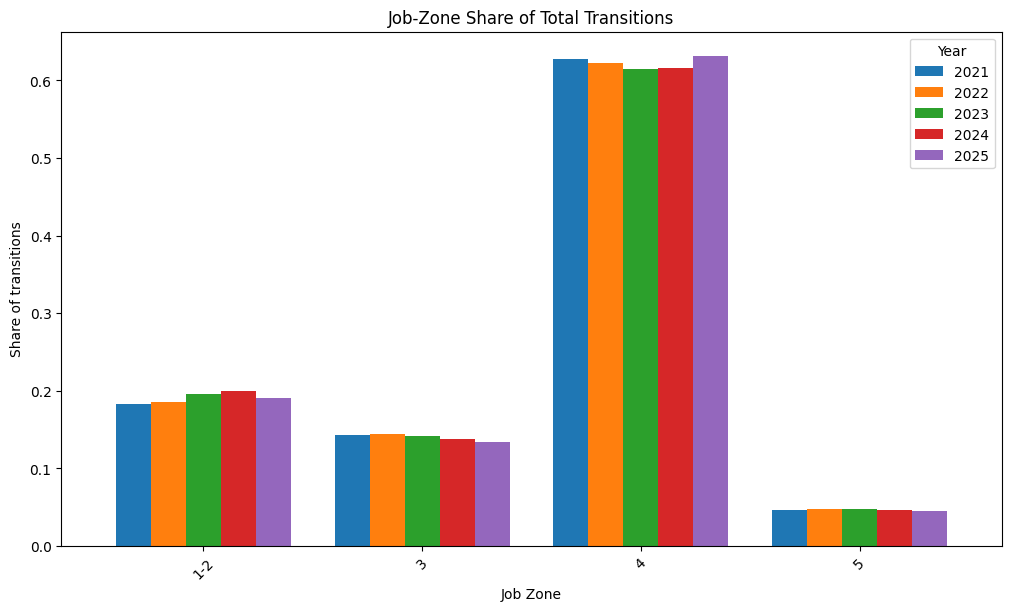

,YEAR,Job Zone,Count,Share
281,2021,1-2,724382,0.182834
282,2021,3,565988,0.142856
283,2021,4,2486313,0.627546
284,2021,5,185278,0.046764
285,2022,1-2,619317,0.185691
286,2022,3,480640,0.144111
287,2022,4,2077619,0.622936
288,2022,5,157627,0.047262
289,2023,1-2,402710,0.196232
290,2023,3,291698,0.142138


In [9]:
zone_share_5y = (
    df.groupby(['YEAR', 'Job Zone'])
    .size()
    .reset_index(name='Count')
)

zone_share_5y['YEAR'] = zone_share_5y['YEAR'].astype(int)
recent_years = sorted(zone_share_5y['YEAR'].unique())[-5:]
zone_share_5y = zone_share_5y[zone_share_5y['YEAR'].isin(recent_years)].copy()
zone_share_5y['Share'] = zone_share_5y['Count'] / zone_share_5y.groupby('YEAR')['Count'].transform('sum')

share_pivot = (
    zone_share_5y.pivot(index='Job Zone', columns='YEAR', values='Share')
    .fillna(0)
    .reindex(columns=recent_years)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
share_pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Job-Zone Share of Total Transitions')
ax.set_xlabel('Job Zone')
ax.set_ylabel('Share of transitions')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Year')
plt.show()

display(zone_share_5y.sort_values(['YEAR', 'Job Zone']))

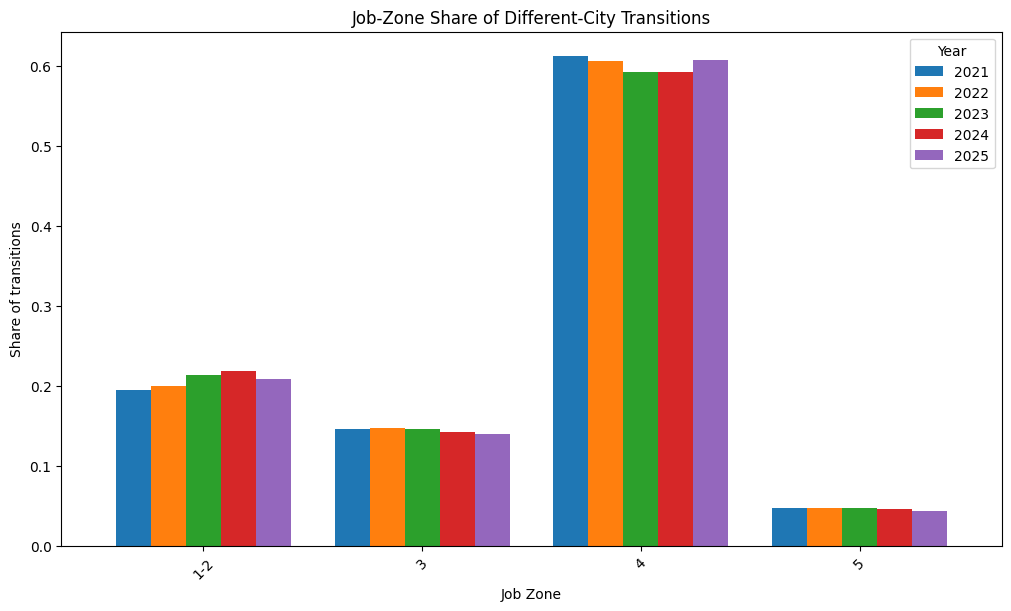

,YEAR,Job Zone,Count,Share
281,2021,1-2,600677,0.194691
282,2021,3,450973,0.146169
283,2021,4,1889227,0.612334
284,2021,5,144411,0.046806
285,2022,1-2,517510,0.199397
286,2022,3,383217,0.147654
287,2022,4,1571969,0.605682
288,2022,5,122674,0.047266
289,2023,1-2,342546,0.213718
290,2023,3,234688,0.146424


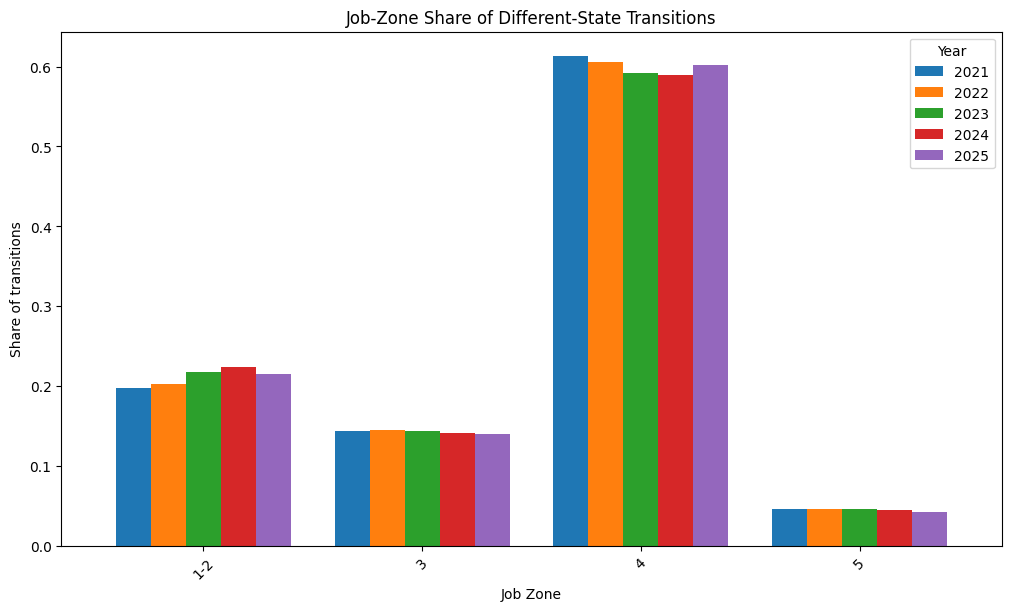

,YEAR,Job Zone,Count,Share
281,2021,1-2,540182,0.197579
282,2021,3,392802,0.143673
283,2021,4,1676120,0.613063
284,2021,5,124904,0.045685
285,2022,1-2,467126,0.202603
286,2022,3,335086,0.145335
287,2022,4,1397278,0.606032
288,2022,5,106129,0.046031
289,2023,1-2,311600,0.218251
290,2023,3,205743,0.144106


In [10]:
import matplotlib.pyplot as plt

def plot_transition_share_by_year(dataframe, title):
    grouped = (
        dataframe.groupby(['YEAR', 'Job Zone'])
        .size()
        .reset_index(name='Count')
    )

    grouped['YEAR'] = grouped['YEAR'].astype(int)
    years = sorted(grouped['YEAR'].unique())[-5:]
    grouped = grouped[grouped['YEAR'].isin(years)].copy()
    grouped['Share'] = grouped['Count'] / grouped.groupby('YEAR')['Count'].transform('sum')

    share_pivot = (
        grouped.pivot(index='Job Zone', columns='YEAR', values='Share')
        .fillna(0)
        .reindex(columns=years)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    share_pivot.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(title)
    ax.set_xlabel('Job Zone')
    ax.set_ylabel('Share of transitions')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Year')
    plt.show()

    display(grouped.sort_values(['YEAR', 'Job Zone']))

plot_transition_share_by_year(
    df[df['FROM_CITY'] != df['TO_CITY']],
    'Job-Zone Share of Different-City Transitions'
 )

plot_transition_share_by_year(
    df[df['FROM_STATE'] != df['TO_STATE']],
    'Job-Zone Share of Different-State Transitions'
 )

- Those most likely to move (relative)

In [11]:
job_zones['ONET'] = job_zones['Code']
df_all_jobs_with_zone = df_all_jobs.merge(
    job_zones,
    left_on='ONET',
    right_on='ONET',
    how='inner'
 )

df_all_jobs_with_zone['Job Zone'] = df_all_jobs_with_zone['Job Zone'].astype(str).str.strip()
jobs_zone_share = (
    df_all_jobs_with_zone.dropna(subset=['Job Zone'])
    .groupby('Job Zone')
    .size()
    .reset_index(name='Count')
    .sort_values('Job Zone')
    .reset_index(drop=True)
 )
jobs_zone_share['Share'] = jobs_zone_share['Count'] / jobs_zone_share['Count'].sum()
jobs_zone_share['Share_pct'] = (100 * jobs_zone_share['Share']).round(2)

display(jobs_zone_share[['Job Zone', 'Count', 'Share', 'Share_pct']])

,Job Zone,Count,Share,Share_pct
0,1-2,12008446,0.185519,18.55
1,3,10078411,0.155701,15.57
2,4,39171218,0.605156,60.52
3,5,3470996,0.053623,5.36


,YEAR,Job Zone,Transition Count,Transition Share,Baseline Job Share,Relative Mobility Index,Excess Share (pp)
2,2020,4,2140225,0.630377,0.605156,1.041676,2.522066
0,2020,1-2,604002,0.177901,0.185519,0.958941,-0.761717
1,2020,3,488175,0.143786,0.155701,0.923472,-1.191547
3,2020,5,162748,0.047935,0.053623,0.893927,-0.568801
6,2021,4,2486313,0.627546,0.605156,1.036998,2.238956
4,2021,1-2,724382,0.182834,0.185519,0.985530,-0.268438
5,2021,3,565988,0.142856,0.155701,0.917496,-1.284594
7,2021,5,185278,0.046764,0.053623,0.872085,-0.685923
10,2022,4,2077619,0.622936,0.605156,1.029380,1.777980
8,2022,1-2,619317,0.185691,0.185519,1.000929,0.017236


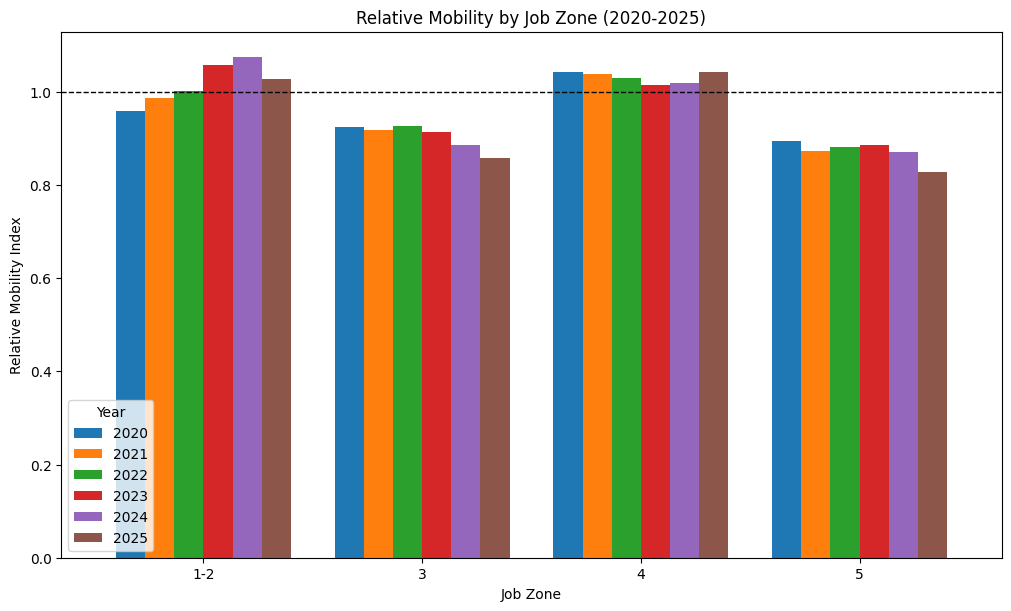

In [12]:
# Relative mobility by year (2020-2025) using df_all_jobs zone shares as baseline
baseline_share = jobs_zone_share[['Job Zone', 'Share']].copy()
baseline_share = baseline_share.rename(columns={'Share': 'Baseline Job Share'})
baseline_share['Job Zone'] = baseline_share['Job Zone'].astype(str).str.strip()

rel_by_year = (
    df.groupby(['YEAR', 'Job Zone'])
    .size()
    .reset_index(name='Transition Count')
)
rel_by_year['YEAR'] = rel_by_year['YEAR'].astype(int)
rel_by_year['Job Zone'] = rel_by_year['Job Zone'].astype(str).str.strip()

year_window = list(range(2020, 2026))
rel_by_year = rel_by_year[rel_by_year['YEAR'].isin(year_window)].copy()

if rel_by_year.empty:
    raise ValueError('No transition rows found for years 2020-2025.')

rel_by_year['Transition Share'] = (
    rel_by_year['Transition Count']
    / rel_by_year.groupby('YEAR')['Transition Count'].transform('sum')
)

relative_mobility = rel_by_year.merge(
    baseline_share,
    on='Job Zone',
    how='left'
 )

if relative_mobility['Baseline Job Share'].isna().any():
    missing_zones = sorted(relative_mobility.loc[
        relative_mobility['Baseline Job Share'].isna(), 'Job Zone'
    ].unique())
    raise ValueError(f'Missing baseline job share for zones: {missing_zones}')

relative_mobility['Relative Mobility Index'] = (
    relative_mobility['Transition Share'] / relative_mobility['Baseline Job Share']
)
relative_mobility['Excess Share (pp)'] = 100 * (
    relative_mobility['Transition Share'] - relative_mobility['Baseline Job Share']
)

display(
    relative_mobility[[
        'YEAR', 'Job Zone', 'Transition Count', 'Transition Share',
        'Baseline Job Share', 'Relative Mobility Index', 'Excess Share (pp)'
    ]].sort_values(['YEAR', 'Relative Mobility Index'], ascending=[True, False])
)

plot_df = (
    relative_mobility.pivot(index='Job Zone', columns='YEAR', values='Relative Mobility Index')
    .sort_index()
    .reindex(columns=[y for y in year_window if y in relative_mobility['YEAR'].unique()])
)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
plot_df.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Relative Mobility by Job Zone (2020-2025)')
ax.set_xlabel('Job Zone')
ax.set_ylabel('Relative Mobility Index')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Year')
plt.show()

,YEAR,Job Zone,Transition Count,Transition Share,Baseline Job Share,Relative Mobility Index,Excess Share (pp)
0,2020,1-2,494423,0.189522,0.185519,1.021579,0.400323
2,2020,4,1604249,0.614939,0.605156,1.016166,0.978291
1,2020,3,384981,0.147571,0.155701,0.947779,-0.813086
3,2020,5,125139,0.047968,0.053623,0.894537,-0.565527
4,2021,1-2,600677,0.194691,0.185519,1.049441,0.917215
6,2021,4,1889227,0.612334,0.605156,1.011861,0.717758
5,2021,3,450973,0.146169,0.155701,0.938776,-0.953261
7,2021,5,144411,0.046806,0.053623,0.872871,-0.681712
8,2022,1-2,517510,0.199397,0.185519,1.074811,1.387880
10,2022,4,1571969,0.605682,0.605156,1.000868,0.052554


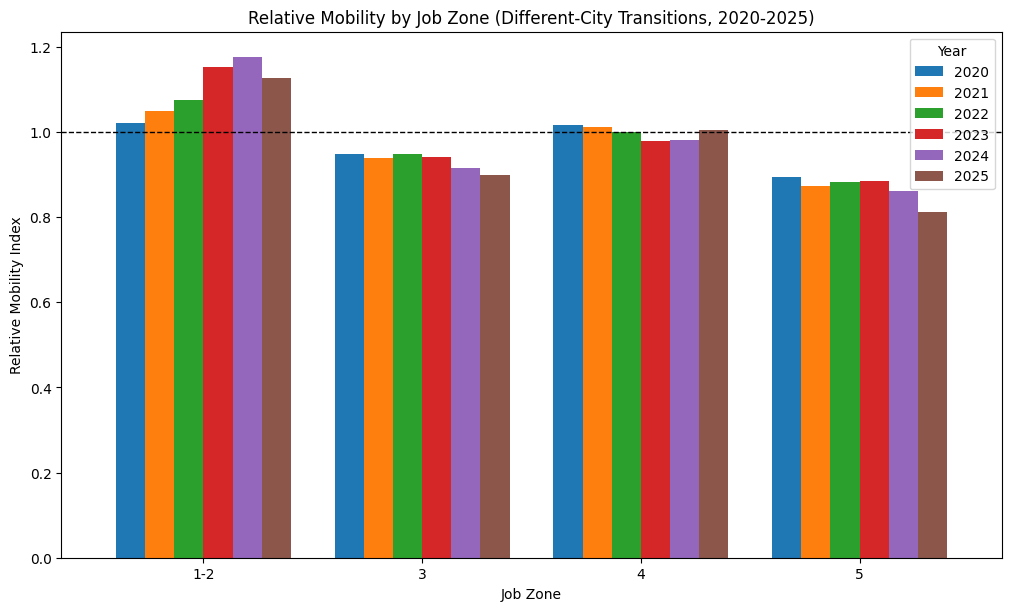

In [13]:
# Relative mobility by year (2020-2025) for transitions to a DIFFERENT city
baseline_share = jobs_zone_share[['Job Zone', 'Share']].copy()
baseline_share = baseline_share.rename(columns={'Share': 'Baseline Job Share'})
baseline_share['Job Zone'] = baseline_share['Job Zone'].astype(str).str.strip()

city_transitions = df[df['FROM_CITY'] != df['TO_CITY']].copy()

rel_city_by_year = (
    city_transitions.groupby(['YEAR', 'Job Zone'])
    .size()
    .reset_index(name='Transition Count')
)
rel_city_by_year['YEAR'] = rel_city_by_year['YEAR'].astype(int)
rel_city_by_year['Job Zone'] = rel_city_by_year['Job Zone'].astype(str).str.strip()

year_window = list(range(2020, 2026))
rel_city_by_year = rel_city_by_year[rel_city_by_year['YEAR'].isin(year_window)].copy()

if rel_city_by_year.empty:
    raise ValueError('No different-city transition rows found for years 2020-2025.')

rel_city_by_year['Transition Share'] = (
    rel_city_by_year['Transition Count']
    / rel_city_by_year.groupby('YEAR')['Transition Count'].transform('sum')
)

relative_mobility_city = rel_city_by_year.merge(
    baseline_share,
    on='Job Zone',
    how='left'
)

if relative_mobility_city['Baseline Job Share'].isna().any():
    missing_zones = sorted(relative_mobility_city.loc[
        relative_mobility_city['Baseline Job Share'].isna(), 'Job Zone'
    ].unique())
    raise ValueError(f'Missing baseline job share for zones: {missing_zones}')

relative_mobility_city['Relative Mobility Index'] = (
    relative_mobility_city['Transition Share'] / relative_mobility_city['Baseline Job Share']
)
relative_mobility_city['Excess Share (pp)'] = 100 * (
    relative_mobility_city['Transition Share'] - relative_mobility_city['Baseline Job Share']
)

display(
    relative_mobility_city[[
        'YEAR', 'Job Zone', 'Transition Count', 'Transition Share',
        'Baseline Job Share', 'Relative Mobility Index', 'Excess Share (pp)'
    ]].sort_values(['YEAR', 'Relative Mobility Index'], ascending=[True, False])
)

plot_city = (
    relative_mobility_city.pivot(index='Job Zone', columns='YEAR', values='Relative Mobility Index')
    .sort_index()
    .reindex(columns=[y for y in year_window if y in relative_mobility_city['YEAR'].unique()])
)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
plot_city.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Relative Mobility by Job Zone (Different-City Transitions, 2020-2025)')
ax.set_xlabel('Job Zone')
ax.set_ylabel('Relative Mobility Index')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Year')
plt.show()

,YEAR,Job Zone,Transition Count,Transition Share,Baseline Job Share,Relative Mobility Index,Excess Share (pp)
0,2020,1-2,444707,0.192315,0.185519,1.036636,0.679662
2,2020,4,1422837,0.615311,0.605156,1.016780,1.015470
1,2020,3,336106,0.145350,0.155701,0.933519,-1.035116
3,2020,5,108736,0.047023,0.053623,0.876917,-0.660016
4,2021,1-2,540182,0.197579,0.185519,1.065008,1.206020
6,2021,4,1676120,0.613063,0.605156,1.013066,0.790681
5,2021,3,392802,0.143673,0.155701,0.922744,-1.202888
7,2021,5,124904,0.045685,0.053623,0.851965,-0.793814
8,2022,1-2,467126,0.202603,0.185519,1.092092,1.708470
10,2022,4,1397278,0.606032,0.605156,1.001446,0.087511


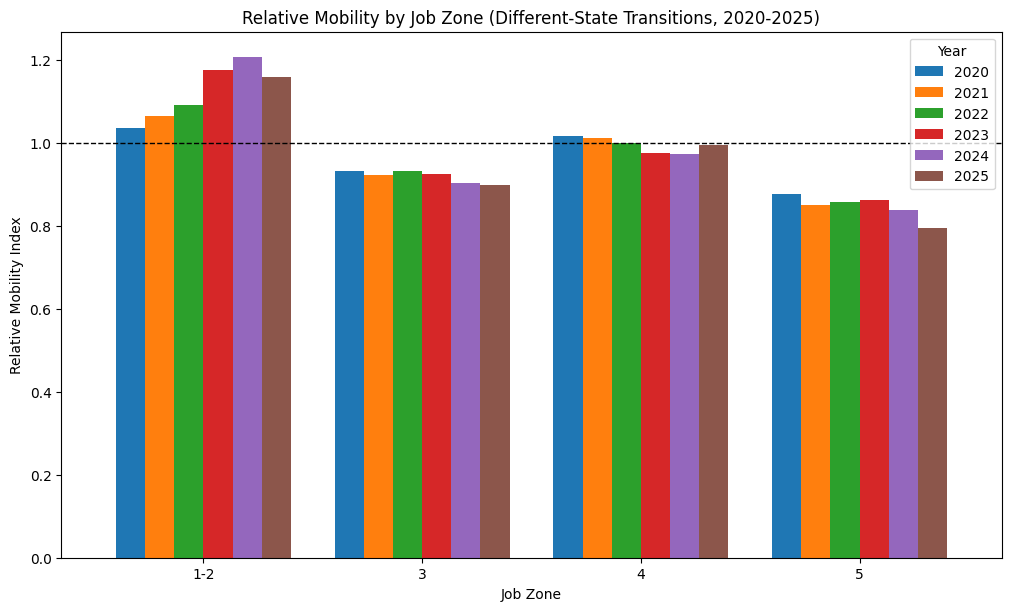

In [14]:
# Relative mobility by year (2020-2025) for transitions to a DIFFERENT state
baseline_share = jobs_zone_share[['Job Zone', 'Share']].copy()
baseline_share = baseline_share.rename(columns={'Share': 'Baseline Job Share'})
baseline_share['Job Zone'] = baseline_share['Job Zone'].astype(str).str.strip()

state_transitions = df[df['FROM_STATE'] != df['TO_STATE']].copy()

rel_state_by_year = (
    state_transitions.groupby(['YEAR', 'Job Zone'])
    .size()
    .reset_index(name='Transition Count')
)
rel_state_by_year['YEAR'] = rel_state_by_year['YEAR'].astype(int)
rel_state_by_year['Job Zone'] = rel_state_by_year['Job Zone'].astype(str).str.strip()

year_window = list(range(2020, 2026))
rel_state_by_year = rel_state_by_year[rel_state_by_year['YEAR'].isin(year_window)].copy()

if rel_state_by_year.empty:
    raise ValueError('No different-state transition rows found for years 2020-2025.')

rel_state_by_year['Transition Share'] = (
    rel_state_by_year['Transition Count']
    / rel_state_by_year.groupby('YEAR')['Transition Count'].transform('sum')
)

relative_mobility_state = rel_state_by_year.merge(
    baseline_share,
    on='Job Zone',
    how='left'
)

if relative_mobility_state['Baseline Job Share'].isna().any():
    missing_zones = sorted(relative_mobility_state.loc[
        relative_mobility_state['Baseline Job Share'].isna(), 'Job Zone'
    ].unique())
    raise ValueError(f'Missing baseline job share for zones: {missing_zones}')

relative_mobility_state['Relative Mobility Index'] = (
    relative_mobility_state['Transition Share'] / relative_mobility_state['Baseline Job Share']
)
relative_mobility_state['Excess Share (pp)'] = 100 * (
    relative_mobility_state['Transition Share'] - relative_mobility_state['Baseline Job Share']
)

display(
    relative_mobility_state[[
        'YEAR', 'Job Zone', 'Transition Count', 'Transition Share',
        'Baseline Job Share', 'Relative Mobility Index', 'Excess Share (pp)'
    ]].sort_values(['YEAR', 'Relative Mobility Index'], ascending=[True, False])
)

plot_state = (
    relative_mobility_state.pivot(index='Job Zone', columns='YEAR', values='Relative Mobility Index')
    .sort_index()
    .reindex(columns=[y for y in year_window if y in relative_mobility_state['YEAR'].unique()])
)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
plot_state.plot(kind='bar', ax=ax, width=0.8)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_title('Relative Mobility by Job Zone (Different-State Transitions, 2020-2025)')
ax.set_xlabel('Job Zone')
ax.set_ylabel('Relative Mobility Index')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Year')
plt.show()